# Titanic Dataset Analysis

## Objective
This notebook analyzes the Titanic dataset using Python, Pandas, Matplotlib, and Seaborn.

---

### Student Notes
_Write your own explanation here._







# 1. Import Required Libraries

This section imports the required libraries for analysis and visualization.







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


# 2. Load Dataset

Load the Titanic dataset using Pandas.

Place `Titanic-Dataset.csv` in the same folder before running the notebook.







In [ ]:
# Load dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Display first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Explore Dataset

Checking dataset shape, data types, and missing values.







In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Shape: (891, 12)

Data Types:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 4. Clean Data

Handle missing values and remove duplicate records.







In [ ]:
# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify cleaned dataset
print("Remaining Missing Values:\n")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:", df.shape)


Remaining Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Dataset Shape After Cleaning: (891, 12)


# 5. Analysis Questions

Answering important questions related to survival patterns.







In [ ]:
# Survival count by gender
survival_by_gender = df.groupby('Sex')['Survived'].sum()

print("Survival Count by Gender:\n")
print(survival_by_gender)

# Survival rate by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean()

print("\nAverage Survival Rate by Passenger Class:\n")
print(survival_by_class)

# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 19, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# Survival rate by age group
survival_by_age = df.groupby('AgeGroup')['Survived'].mean()

print("\nSurvival Rate by Age Group:\n")
print(survival_by_age)


Survival Count by Gender:

Sex
female    233
male      109
Name: Survived, dtype: int64

Average Survival Rate by Passenger Class:

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:

AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_614/4287795811.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean()


# 6. Visualization: Survival by Gender

Bar chart showing survival counts for males and females.







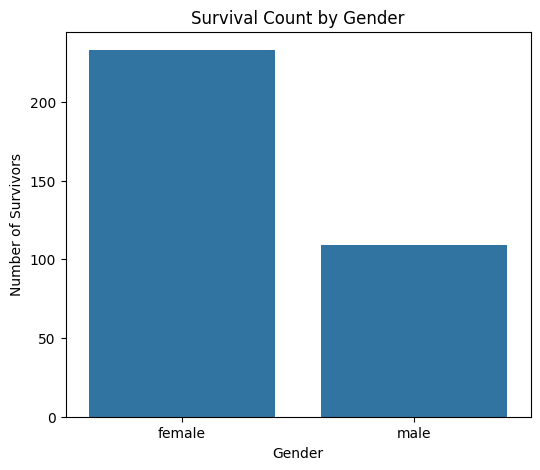

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x=survival_by_gender.index, y=survival_by_gender.values)

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Survivors')

plt.show()


# 7. Visualization: Survival by Passenger Class

Bar chart showing average survival rate by passenger class.







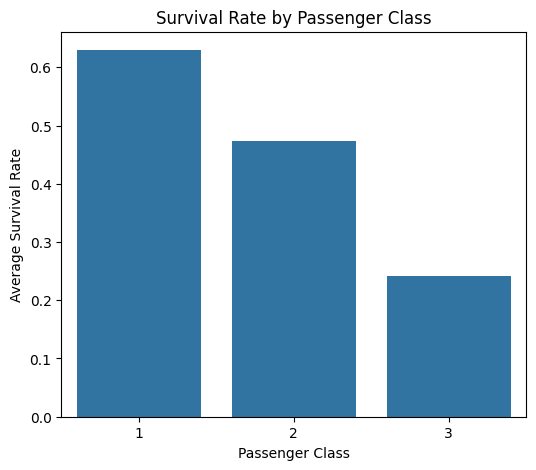

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x=survival_by_class.index, y=survival_by_class.values)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Survival Rate')

plt.show()


# 8. Visualization: Histogram of Passenger Ages

Histogram showing age distribution of passengers.







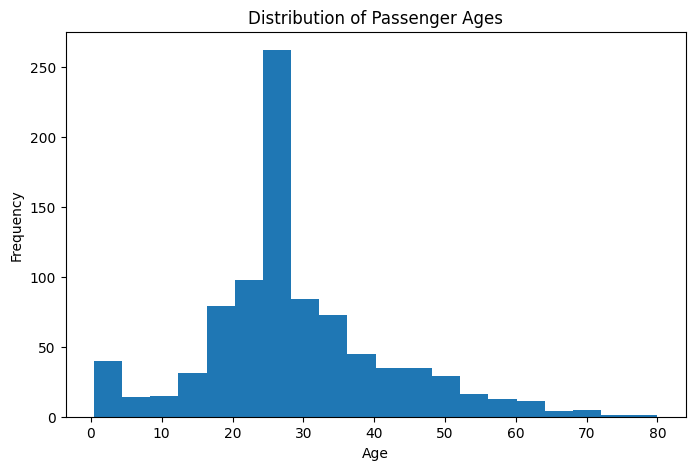

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()


# 9. Conclusion













Based on the analysis, the following observations can be made:

*   **Gender:** A significantly higher number of females survived compared to males, indicating that gender was a strong factor in survival.
*   **Passenger Class:** First-class passengers had a much higher average survival rate than second and third-class passengers, suggesting that socio-economic status or proximity to lifeboats played a role.
*   **Age:** Children had a relatively high survival rate, followed by adults and young adults. Seniors had the lowest survival rate among the age groups. Teens had a survival rate similar to that of young adults and adults.